In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [4]:
df = pd.read_csv("Zomato-data-.csv")
print(f"Dataset shape: {df.shape}")

Dataset shape: (148, 7)


In [5]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
dtypes: int64(2), str(5)
memory usage: 8.2 KB


In [7]:
# Check missing values
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [8]:
# Check duplicates
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


In [9]:
# Extract numeric rating from rate column
df['rating'] = df['rate'].str.extract(r'(\d+\.?\d*)').astype(float)
df['rating'].fillna(df['rating'].median(), inplace=True)

# Rename cost column for easier access
df['cost'] = df['approx_cost(for two people)']

print(f"Rating range: {df['rating'].min()} - {df['rating'].max()}")
print(f"Cost range: {df['cost'].min()} - {df['cost'].max()}")

Rating range: 2.6 - 4.6
Cost range: 100 - 950


In [10]:
df.describe()

,votes,approx_cost(for two people),rating,cost
count,148.000000,148.000000,148.000000,148.000000
mean,264.810811,418.243243,3.633108,418.243243
std,653.676951,223.085098,0.402271,223.085098
min,0.000000,100.000000,2.600000,100.000000
25%,6.750000,200.000000,3.300000,200.000000
50%,43.500000,400.000000,3.700000,400.000000
75%,221.750000,600.000000,3.900000,600.000000
max,4884.000000,950.000000,4.600000,950.000000


In [11]:
# Restaurant types
df['listed_in(type)'].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

In [12]:
# Online order distribution
df['online_order'].value_counts()

online_order
No     90
Yes    58
Name: count, dtype: int64

In [13]:
# Table booking distribution
df['book_table'].value_counts()

book_table
No     140
Yes      8
Name: count, dtype: int64

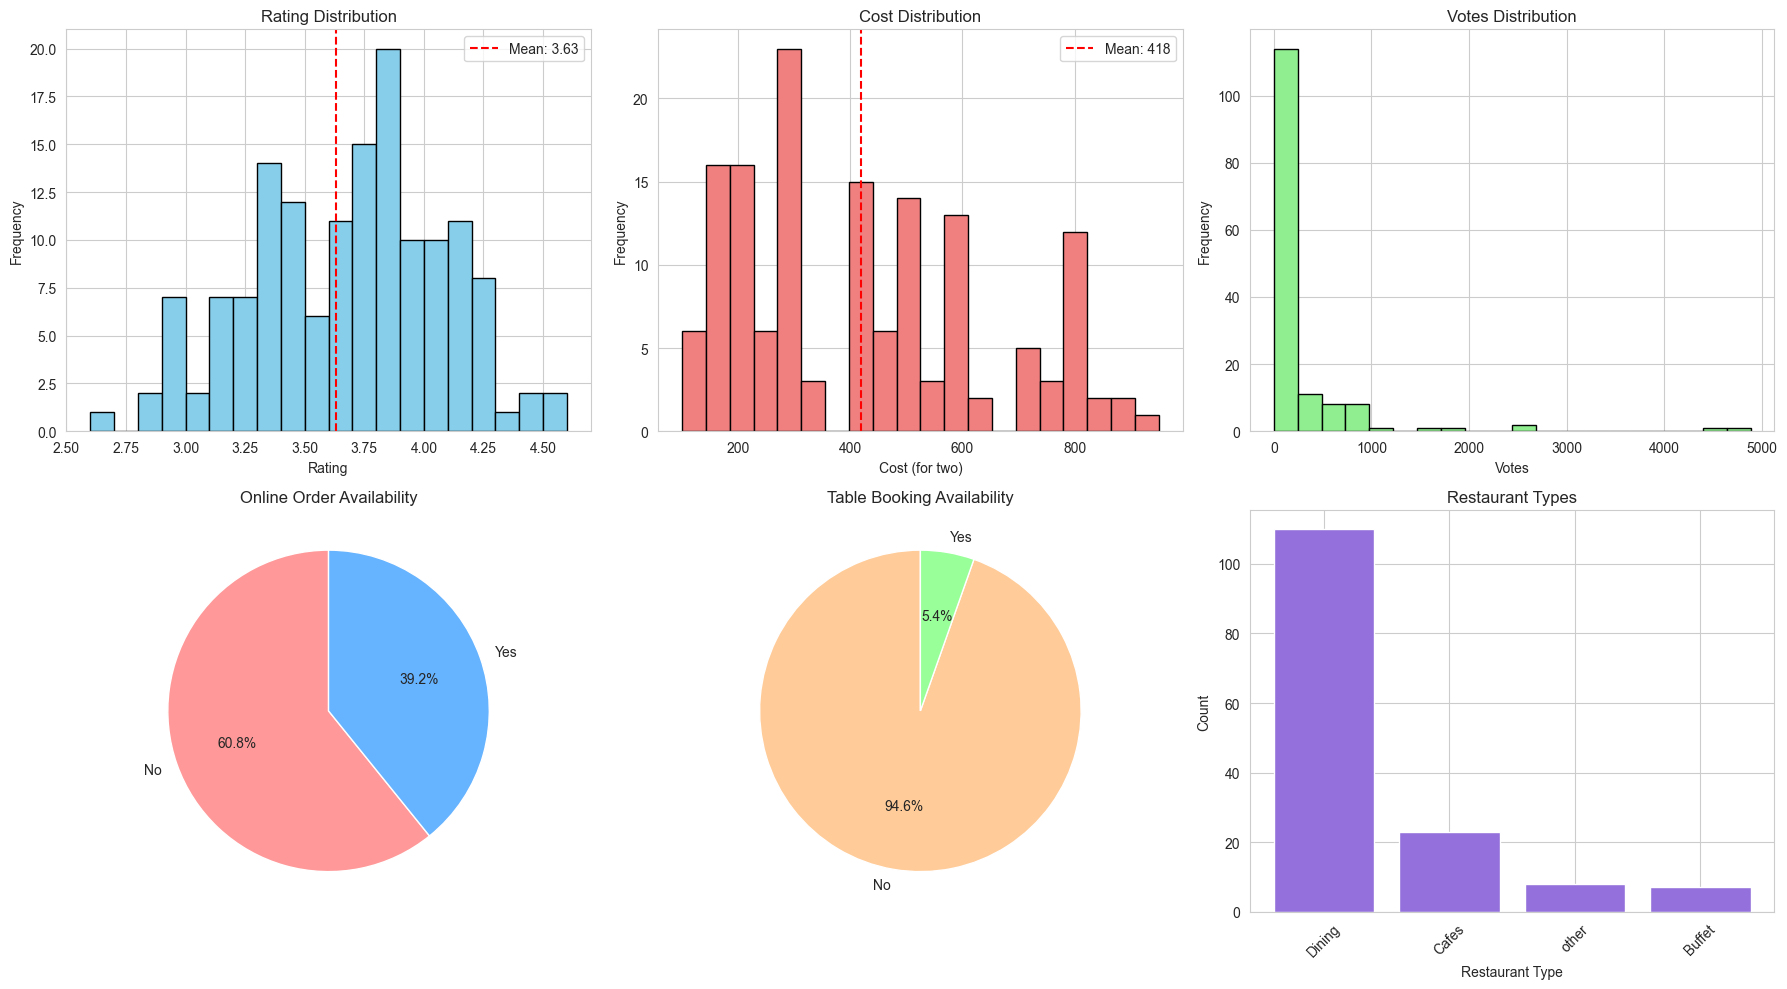

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Rating distribution
axes[0, 0].hist(df['rating'], bins=20, color='skyblue', edgecolor='black')
axes[0, 0].axvline(df['rating'].mean(), color='red', linestyle='--', label=f'Mean: {df["rating"].mean():.2f}')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Rating Distribution')
axes[0, 0].legend()

# Cost distribution
axes[0, 1].hist(df['cost'], bins=20, color='lightcoral', edgecolor='black')
axes[0, 1].axvline(df['cost'].mean(), color='red', linestyle='--', label=f'Mean: {df["cost"].mean():.0f}')
axes[0, 1].set_xlabel('Cost (for two)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Cost Distribution')
axes[0, 1].legend()

# Votes distribution
axes[0, 2].hist(df['votes'], bins=20, color='lightgreen', edgecolor='black')
axes[0, 2].set_xlabel('Votes')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('Votes Distribution')

# Online order pie chart
online_counts = df['online_order'].value_counts()
axes[1, 0].pie(online_counts, labels=online_counts.index, autopct='%1.1f%%', 
               colors=['#ff9999', '#66b3ff'], startangle=90)
axes[1, 0].set_title('Online Order Availability')

# Table booking pie chart
booking_counts = df['book_table'].value_counts()
axes[1, 1].pie(booking_counts, labels=booking_counts.index, autopct='%1.1f%%',
               colors=['#ffcc99', '#99ff99'], startangle=90)
axes[1, 1].set_title('Table Booking Availability')

# Restaurant types
type_counts = df['listed_in(type)'].value_counts()
axes[1, 2].bar(range(len(type_counts)), type_counts.values, color='mediumpurple')
axes[1, 2].set_xticks(range(len(type_counts)))
axes[1, 2].set_xticklabels(type_counts.index, rotation=45)
axes[1, 2].set_xlabel('Restaurant Type')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Restaurant Types')

plt.tight_layout()
plt.show()

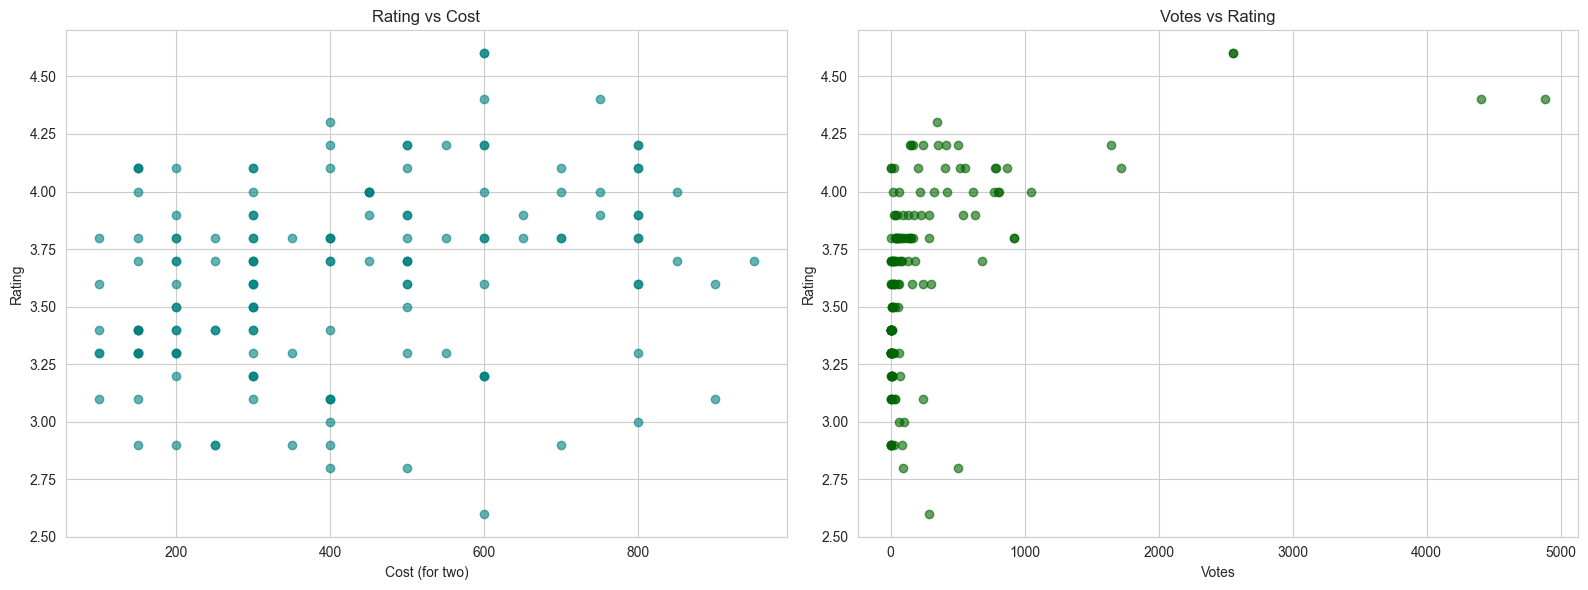

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rating vs Cost
axes[0].scatter(df['cost'], df['rating'], alpha=0.6, color='teal')
axes[0].set_xlabel('Cost (for two)')
axes[0].set_ylabel('Rating')
axes[0].set_title('Rating vs Cost')

# Votes vs Rating
axes[1].scatter(df['votes'], df['rating'], alpha=0.6, color='darkgreen')
axes[1].set_xlabel('Votes')
axes[1].set_ylabel('Rating')
axes[1].set_title('Votes vs Rating')

plt.tight_layout()
plt.show()

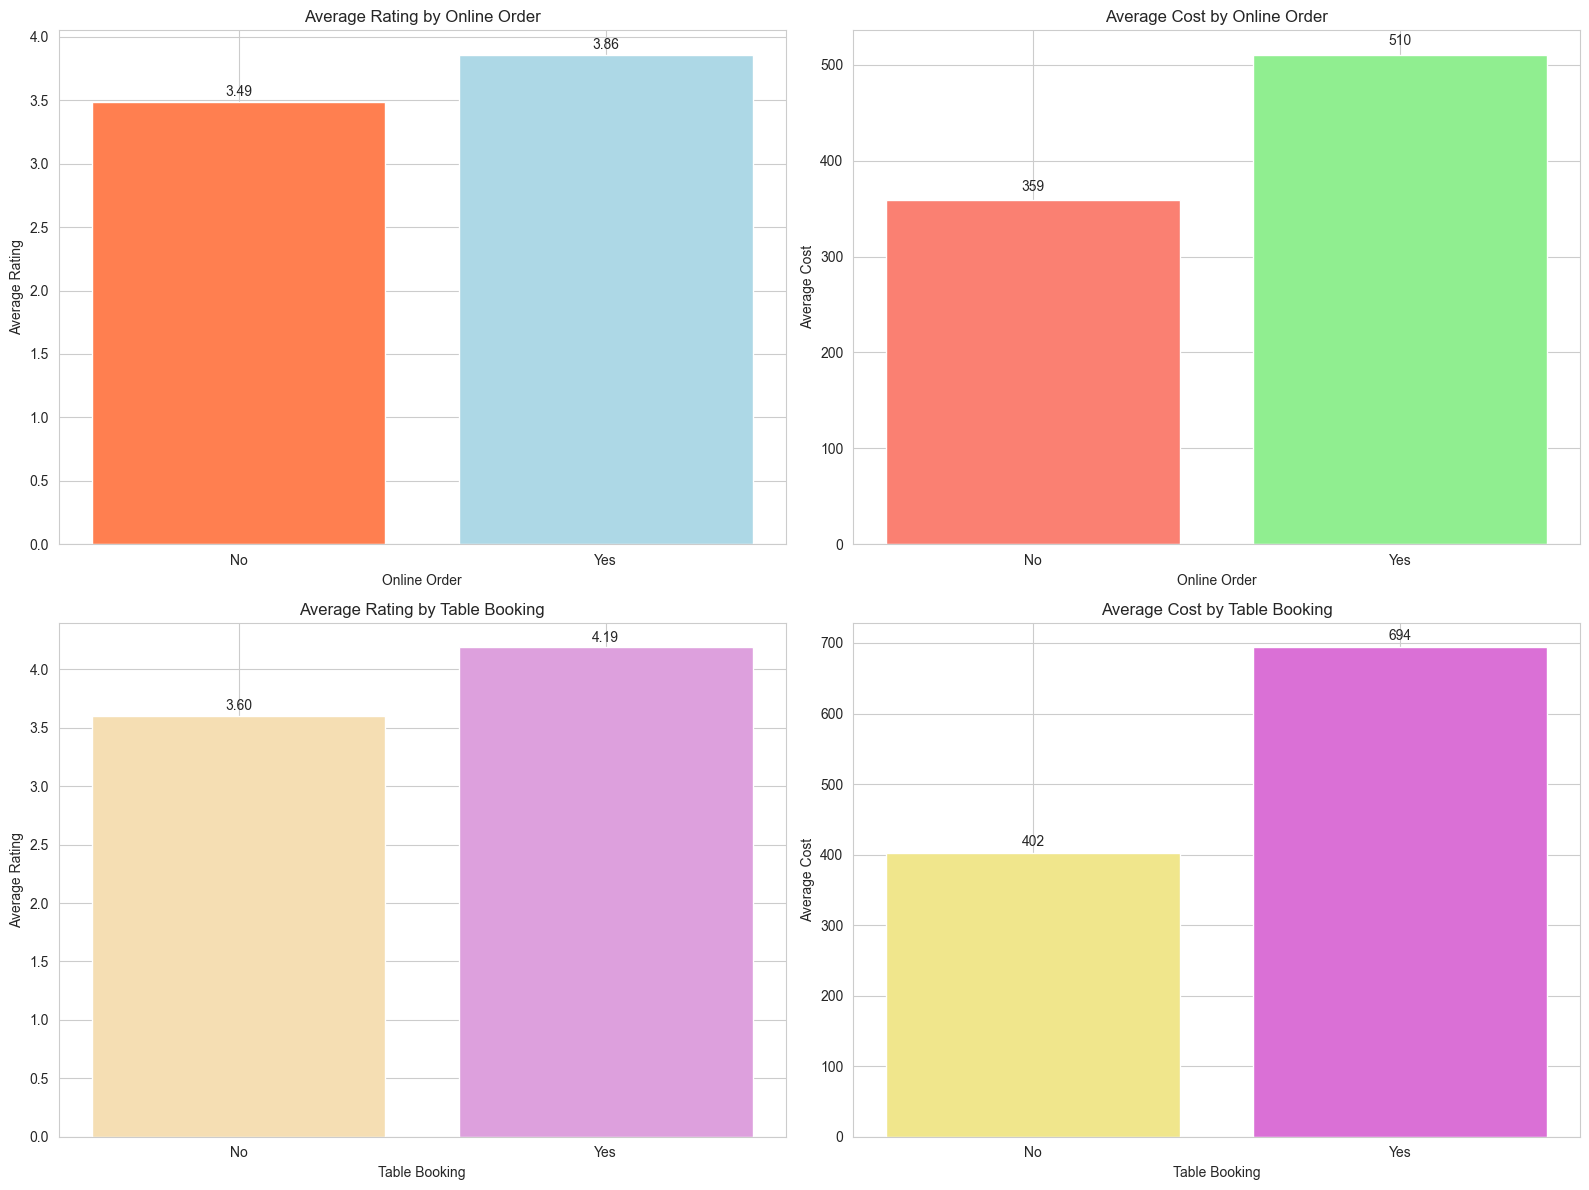

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Average rating by online order
online_rating = df.groupby('online_order')['rating'].mean()
axes[0, 0].bar(online_rating.index, online_rating.values, color=['coral', 'lightblue'])
axes[0, 0].set_xlabel('Online Order')
axes[0, 0].set_ylabel('Average Rating')
axes[0, 0].set_title('Average Rating by Online Order')
for i, v in enumerate(online_rating.values):
    axes[0, 0].text(i, v + 0.05, f'{v:.2f}', ha='center')

# Average cost by online order
online_cost = df.groupby('online_order')['cost'].mean()
axes[0, 1].bar(online_cost.index, online_cost.values, color=['salmon', 'lightgreen'])
axes[0, 1].set_xlabel('Online Order')
axes[0, 1].set_ylabel('Average Cost')
axes[0, 1].set_title('Average Cost by Online Order')
for i, v in enumerate(online_cost.values):
    axes[0, 1].text(i, v + 10, f'{v:.0f}', ha='center')

# Average rating by table booking
booking_rating = df.groupby('book_table')['rating'].mean()
axes[1, 0].bar(booking_rating.index, booking_rating.values, color=['wheat', 'plum'])
axes[1, 0].set_xlabel('Table Booking')
axes[1, 0].set_ylabel('Average Rating')
axes[1, 0].set_title('Average Rating by Table Booking')
for i, v in enumerate(booking_rating.values):
    axes[1, 0].text(i, v + 0.05, f'{v:.2f}', ha='center')

# Average cost by table booking
booking_cost = df.groupby('book_table')['cost'].mean()
axes[1, 1].bar(booking_cost.index, booking_cost.values, color=['khaki', 'orchid'])
axes[1, 1].set_xlabel('Table Booking')
axes[1, 1].set_ylabel('Average Cost')
axes[1, 1].set_title('Average Cost by Table Booking')
for i, v in enumerate(booking_cost.values):
    axes[1, 1].text(i, v + 10, f'{v:.0f}', ha='center')

plt.tight_layout()
plt.show()

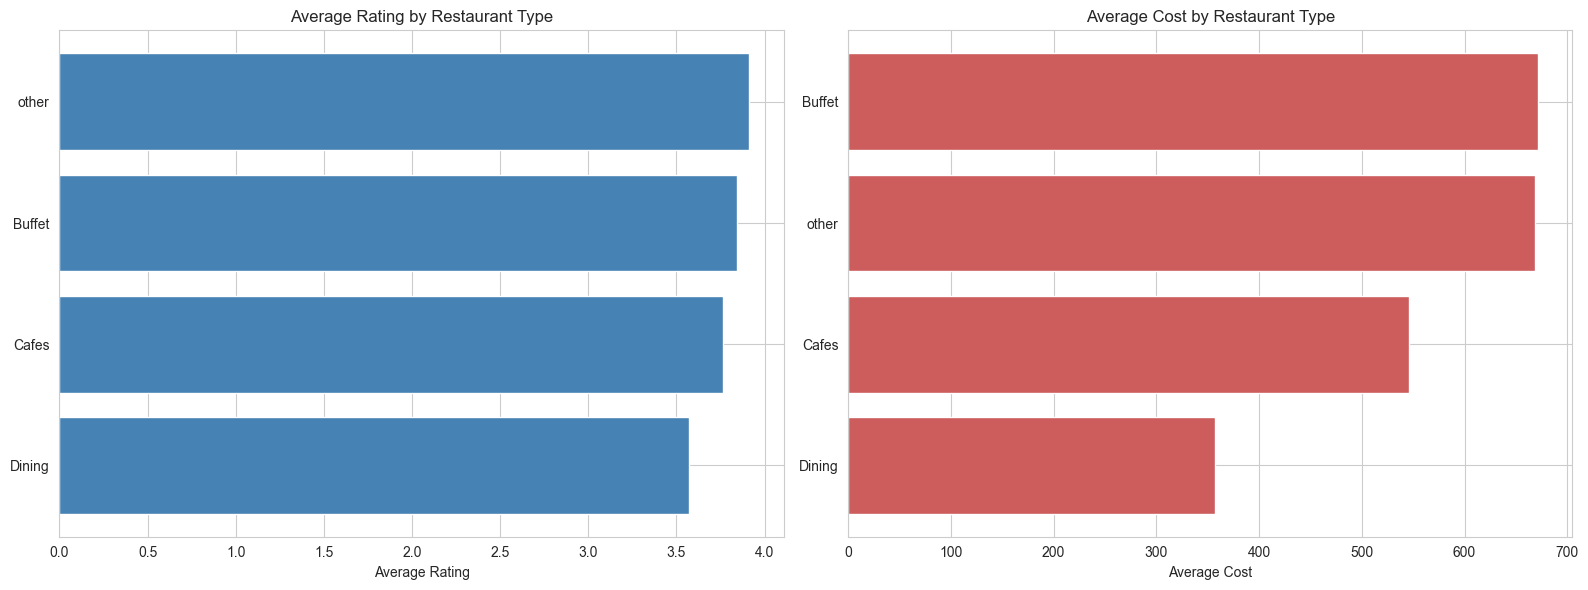

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average rating by restaurant type
type_rating = df.groupby('listed_in(type)')['rating'].mean().sort_values(ascending=False)
axes[0].barh(range(len(type_rating)), type_rating.values, color='steelblue')
axes[0].set_yticks(range(len(type_rating)))
axes[0].set_yticklabels(type_rating.index)
axes[0].set_xlabel('Average Rating')
axes[0].set_title('Average Rating by Restaurant Type')
axes[0].invert_yaxis()

# Average cost by restaurant type
type_cost = df.groupby('listed_in(type)')['cost'].mean().sort_values(ascending=False)
axes[1].barh(range(len(type_cost)), type_cost.values, color='indianred')
axes[1].set_yticks(range(len(type_cost)))
axes[1].set_yticklabels(type_cost.index)
axes[1].set_xlabel('Average Cost')
axes[1].set_title('Average Cost by Restaurant Type')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

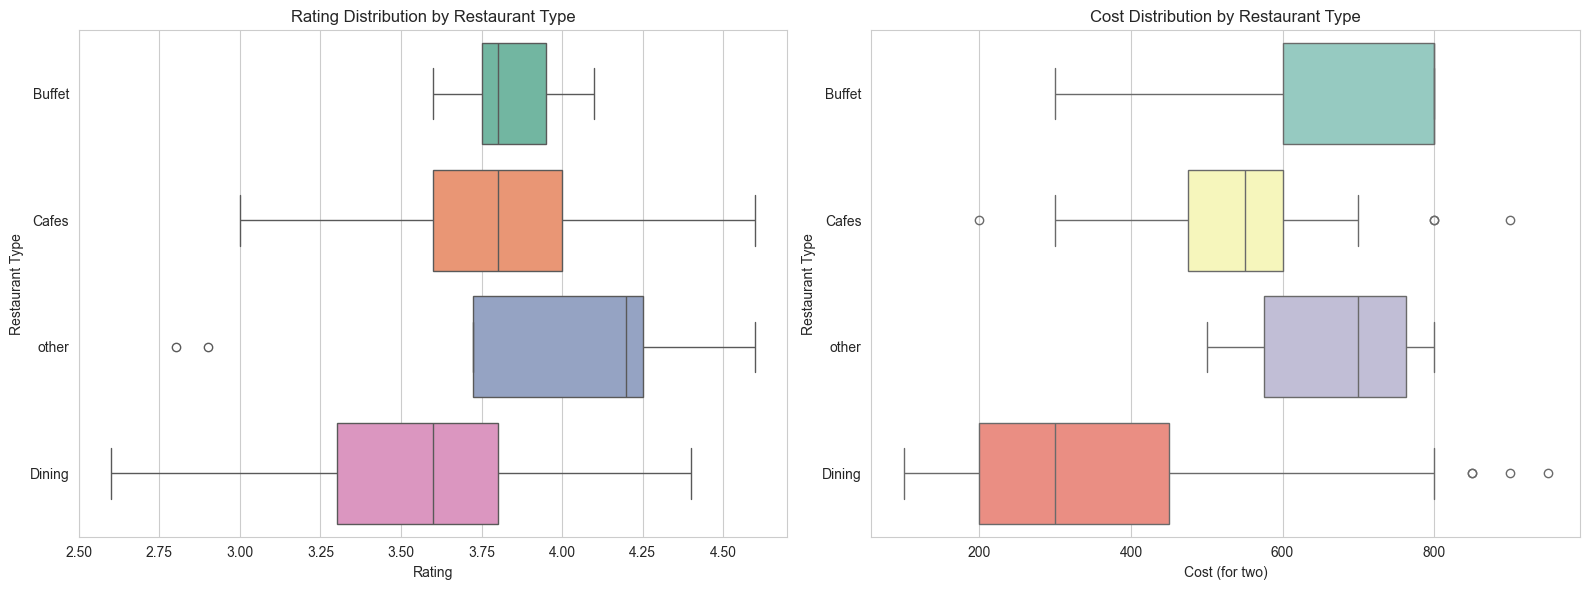

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rating distribution by restaurant type
sns.boxplot(data=df, y='listed_in(type)', x='rating', ax=axes[0], palette='Set2')
axes[0].set_title('Rating Distribution by Restaurant Type')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Restaurant Type')

# Cost distribution by restaurant type
sns.boxplot(data=df, y='listed_in(type)', x='cost', ax=axes[1], palette='Set3')
axes[1].set_title('Cost Distribution by Restaurant Type')
axes[1].set_xlabel('Cost (for two)')
axes[1].set_ylabel('Restaurant Type')

plt.tight_layout()
plt.show()

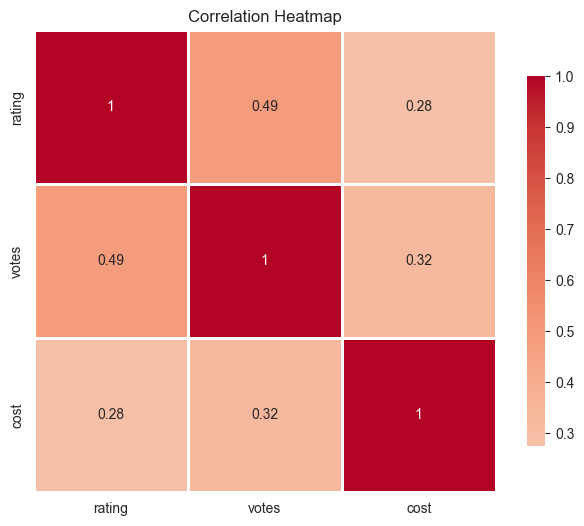

In [19]:
# Select numeric columns
numeric_df = df[['rating', 'votes', 'cost']]
correlation = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap')
plt.show()

In [20]:
print("Key Statistics:")
print(f"Average Rating: {df['rating'].mean():.2f}")
print(f"Average Cost: {df['cost'].mean():.0f}")
print(f"Average Votes: {df['votes'].mean():.0f}")
print(f"\nOnline Ordering: {(df['online_order'] == 'Yes').sum() / len(df) * 100:.1f}%")
print(f"Table Booking: {(df['book_table'] == 'Yes').sum() / len(df) * 100:.1f}%")
print(f"\nMost Common Type: {df['listed_in(type)'].mode()[0]}")

Key Statistics:
Average Rating: 3.63
Average Cost: 418
Average Votes: 265

Online Ordering: 39.2%
Table Booking: 5.4%

Most Common Type: Dining


In [21]:
print("Comparative Analysis:")
print(f"\nOnline Order - Yes: Rating = {df[df['online_order'] == 'Yes']['rating'].mean():.2f}")
print(f"Online Order - No:  Rating = {df[df['online_order'] == 'No']['rating'].mean():.2f}")
print(f"\nTable Booking - Yes: Rating = {df[df['book_table'] == 'Yes']['rating'].mean():.2f}")
print(f"Table Booking - No:  Rating = {df[df['book_table'] == 'No']['rating'].mean():.2f}")

Comparative Analysis:

Online Order - Yes: Rating = 3.86
Online Order - No:  Rating = 3.49

Table Booking - Yes: Rating = 4.19
Table Booking - No:  Rating = 3.60
